# RAG Implementation with AzureOpenAI and LangChain

In [ ]:
!python -m pip install langchain-community langchainhub langchain-chroma langchain langchain-experimental --quiet

In [ ]:
!python -m pip install langgraph pypdf faiss-cpu --quiet

In [ ]:
import os

embedding_model_name = "text-embedding-ada-002"
model_name = "gpt-4o-mini"

In [ ]:
doc_paths = ["https://www.morningstar.com/content/dam/marketing/shared/research/methodology/771945_Morningstar_Rating_for_Funds_Methodology.pdf",
             "https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf",
             "https://s21.q4cdn.com/198919461/files/doc_downloads/press_kits/2016/Morningstar-Sustainable-Investing-Handbook.pdf"]

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

#loaders = [PyPDFLoader(pdf, extract_images=False,mode='single') for pdf in doc_paths]
loaders = [PyPDFLoader(pdf, extract_images=False) for pdf in doc_paths]
docs = []

for loader in loaders:
    doc = loader.load()
    docs.extend(doc)

In [ ]:
len(docs)

46

In [ ]:
docs[0]

Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2021-08-26T06:25:29-04:00', 'moddate': '2021-08-26T06:25:33-04:00', 'trapped': '/False', 'source': 'https://www.morningstar.com/content/dam/marketing/shared/research/methodology/771945_Morningstar_Rating_for_Funds_Methodology.pdf', 'total_pages': 21, 'page': 0, 'page_label': '1'}, page_content='The Morningstar Rating\nTM\n for Funds\nMorningstar Methodology\nAugust 2021\nContents\nIntroduction \nMorningstar Categories \nTheory \nCalculations \nThe Morningstar Rating: \nThree-, Five-, and 10-Year \nMorningstar Return and \nMorningstar Risk Rating\nThe Overall Morningstar Rating\nRating Suspensions\nConclusion\nAppendix 1: Risk-Free Rates Applied\nAppendix 2: Methodology Changes\nAppendix 3: Star Ratings for Separately\nManaged Accounts and Models\nImportant Disclosure\nMerged with the existing star rating\nThe conduct of Morningstar’s analysts is governed \nby Code of 

In [ ]:
# drop pages which have less than 100 characters (e.g. header pages, empty separater pages)
docs = [doc for doc in docs if len(doc.page_content.strip())>100]
len(docs)

45

In [ ]:
# FOr all remaining document, checking the average characters count
sum(len(doc.page_content) for doc in docs)/len(docs)

2707.9555555555557

In [ ]:
2707*1.5

4060.5

In [ ]:
!pip install langchain-text-splitters

In [ ]:
# split the documents(each pdf page as one document) , into multiple so that at max there are 3500 characters in one document, with overlap of 500 characters while splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=3500, chunk_overlap=500)
splits = text_splitter.split_documents(docs)
len(splits)

53

In [ ]:
print(splits[1].page_content)

3
3
3
©2021 Morningstar, Inc. All rights reserved. The information in this document is the property of Morningstar, Inc. Reproduction or transcription by any means, in whole or in part, without the prior written 
consent of Morningstar, Inc., is prohibited.
 
The Morningstar RatingTM for Funds    August 2021Page 2 of 21
captured by standard deviation, as would be the case if excess return were normally or lognormally 
distributed, which is not always the case. Also, standard deviation measures variation both above 
and below the mean equally. But investors are generally risk-averse and dislike downside variation 
more than upside variation. Morningstar gives more weight to downside variation when calculating 
Morningstar Risk-Adjusted Return and does not make any assumptions about the distribution of 
excess returns.
The other commonly accepted meaning of “risk-adjusted” is based on assumed investor preferences. 
Under this approach, higher return is “good” and higher risk is “bad” und

In [ ]:
!pip install langchain_openai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os

os.environ['AZURE_OPENAI_API_KEY']=''
os.environ['AZURE_OPENAI_ENDPOINT']='https://xx.openai.azure.com/'
os.environ['AZURE_OPENAI_API_VERSION']="2024-08-01-preview"
os.environ['OPENAI_API_VERSION']="2024-08-01-preview"
os.environ['AZURE_OPENAI_DEPLOYMENT']="gpt-4o-mini"
os.environ['TAVILY_API_KEY']='tvly-dev-'
os.environ['OPENWEATHERMAP_API_KEY']='x'

In [ ]:
from langchain_openai import AzureOpenAIEmbeddings
embeddings = AzureOpenAIEmbeddings(model=embedding_model_name)

In [ ]:
import os
vector_db_path = "VectorDB_Chroma"
os.makedirs(vector_db_path,exist_ok=True)

In [ ]:
from langchain_chroma import Chroma
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings,
                                    persist_directory=vector_db_path,collection_name="morningstar2",
                                    collection_metadata={"use_type":"TRAINING AND EXPERIMENTATION"})


In [ ]:
print("Number of docs dumped into vector DB")
print(len(vectorstore.get()['ids']))

Number of docs dumped into vector DB
53


In [ ]:
# using vector db object to initialize a retriever object - to perform vector search/retrieval
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 2})

In [ ]:
retrieved_docs = retriever.invoke("What is large cap equity fund?")
len(retrieved_docs)

2

In [ ]:
print(retrieved_docs[0])

page_content='? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. Funds in this 
category would invest at least 65% of their total assets in mid-cap stocks. 
Morningstar Category Index: S&P BSE Mid Cap TR 
 
Small-Cap 

In [ ]:
ret_docs = vectorstore.similarity_search_with_score("What is Large Cap equity fund",k=2)
print(ret_docs[0])

(Document(id='a538551b-fffb-41f6-9b73-37be2e9c23b0', metadata={'total_pages': 12, 'creationdate': '2021-02-26T12:11:18+05:30', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'page': 0, 'page_label': '1', 'producer': 'GPL Ghostscript 9.06', 'moddate': '2021-02-26T12:11:18+05:30', 'author': 'KBelapu', 'creator': 'PScript5.dll Version 5.2.2', 'title': 'Microsoft Word - India Category_Definitions April 2021'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total assets in large-cap stocks. \nMorningstar Category Index: S&P BS

In [ ]:
print(retrieved_docs[0].page_content)

? 
 
 
 
 
 
 
 
 
 
 
 
Categor y Definitions  
India 
Equity  
 
Large-Cap 
Large-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of 
the equity market. These funds invest at least 80% of total assets in Indian equities and the balance can 
be invested in other asset classes such as fixed income and overseas equities, among others. Funds in 
this category would invest at least 80% of their total assets in large-cap stocks. 
Morningstar Category Index: S&P BSE 100 TR 
 
Mid-Cap 
Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the 
equity market. These funds invest at least 65% of total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. Funds in this 
category would invest at least 65% of their total assets in mid-cap stocks. 
Morningstar Category Index: S&P BSE Mid Cap TR 
 
Small-Cap 
Small-Cap fun

In [ ]:
print(retrieved_docs[1].page_content)

©2019 Morningstar, Inc. All rights reserved. The information in this document is the property of Morningstar, Inc. Reproduction or transcription by any means, in whole or part, without  
the prior written consent of Morningstar, Inc., is prohibited. 
Category Definitions , India  | 26 February 2021  Page 2 of 12  
Multi- Cap 
Multi-Cap funds invest at least 75% of their total assets in Indian equities, and the balance can be 
invested in other asset classes such as fixed income and overseas equities, among others. These funds 
will invest a minimum of 25% each in Large Cap, Mid Cap and Small Cap stocks. 
Morningstar Category Index: S&P BSE 500 TR 
 
 
Large & Mid- Cap 
Large & Mid-Cap funds primarily consist of stocks which are the Top 250 stocks by full market 
capitalization of the equity market. These funds invest at least 70% of total assets in Indian equities and 
the balance can be invested in other asset classes such as fixed income and overseas equities, among 
others. Funds in

### Implementing RAG Chain

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough

message = """
Answer this question using the provided context only. If the context does not have the content to answer the question,
say context is irrelevant.
Do not make up the answer, do not provide answer from outside the context.
{question}

Context:
{context}
"""

prompt = PromptTemplate.from_template(message)
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='\nAnswer this question using the provided context only. If the context does not have the content to answer the question, \nsay context is irrelevant.\nDo not make up the answer, do not provide answer from outside the context.\n{question}\n\nContext:\n{context}\n')

In [ ]:
obj1 = RunnablePassthrough()
obj1.invoke("tell me about mid cap market")

'tell me about mid cap market'

In [ ]:
retriever.invoke("tell me about mid cap market")

[Document(id='a538551b-fffb-41f6-9b73-37be2e9c23b0', metadata={'moddate': '2021-02-26T12:11:18+05:30', 'total_pages': 12, 'page': 0, 'creationdate': '2021-02-26T12:11:18+05:30', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'page_label': '1', 'creator': 'PScript5.dll Version 5.2.2', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'author': 'KBelapu', 'producer': 'GPL Ghostscript 9.06'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total assets in large-cap stocks. \nMorningstar Category Index: S&P BS

In [ ]:
!pip install langchain_openai openai pyowm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 52.5 MB/s eta 0:00:00


In [ ]:
from langchain_openai import AzureChatOpenAI
llm = AzureChatOpenAI(model=model_name)

rag_chain = {"context": retriever, "question": RunnablePassthrough()} | prompt | llm


In [ ]:
response = rag_chain.invoke("tell me about mid cap market")

print(response.content)

Mid-Cap funds primarily consist of stocks ranked 101st to 250th by full market capitalization of the equity market. These funds invest at least 65% of total assets in Indian equities, with the balance potentially allocated to other asset classes such as fixed income and overseas equities. The Morningstar Category Index for Mid-Cap funds is the S&P BSE Mid Cap TR.


## RAG Chain with Langgraph - with Routing

In [ ]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class mystate(TypedDict):
    question:str
    context: List[Document]
    answer: str

In [ ]:
# retriever node
def retrieve(state:mystate)->mystate:
    retrieved_docs =  retriever.invoke(state['question'])
    return {"context":retrieved_docs}


# generation node
def generate(state:mystate)->mystate:
    doc_content = "\n\n".join(doc.page_content for doc in state['context'])
    messages = prompt.invoke({"question":state['question'],"context":doc_content})
    response = llm.invoke(messages)
    return {"answer":response.content}


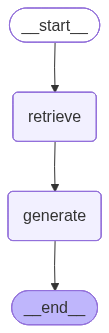

In [ ]:
from langgraph.graph import START, StateGraph

builder = StateGraph(mystate)
builder.add_sequence([retrieve,generate])
builder.add_edge(START,"retrieve")
graph = builder.compile()
graph

In [ ]:
response = graph.invoke({"question":"what is large cap equity fund?"})
response

{'question': 'what is large cap equity fund?',
 'context': [Document(id='a538551b-fffb-41f6-9b73-37be2e9c23b0', metadata={'author': 'KBelapu', 'page': 0, 'creator': 'PScript5.dll Version 5.2.2', 'title': 'Microsoft Word - India Category_Definitions April 2021', 'page_label': '1', 'producer': 'GPL Ghostscript 9.06', 'source': 'https://www.morningstar.in/docs/methodology/CategoryDefinitionsIndiaV3.pdf', 'moddate': '2021-02-26T12:11:18+05:30', 'total_pages': 12, 'creationdate': '2021-02-26T12:11:18+05:30'}, page_content='? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total asset

## Agentic RAG

In [ ]:
# convert retriever as a tool

from langchain_core.tools import tool

@tool
def get_finance_knowledge_retriever_tool(question: str) -> str:
    """
    Use this tool to retrieve finance, investment, trading related information from Morningstar documents.
    you can ask about fund ratings, fund categories, sustainable investing, investment strategies, risk management etc.
    while using this tool, make sure from user that they are looking for information ONLY from india.

    you can rewrite the query from investment specific context

    input:
    question: str : The question related to finance, investment, trading for which information is to be retrieved from Morningstar documents.
    output:
    doc_content str : The retrieved information from the documents.
    source: str : The source document information from which the content is retrieved.
    """
    retrieved_docs =  retriever.invoke(question)
    doc_content = "\n\n".join(doc.page_content for doc in retrieved_docs)
    source = "\n\n".join(f"Source-{i+1}:\n{doc.metadata.get('source','No Source Info')}" for i,doc in enumerate(retrieved_docs))

    return doc_content, source

In [ ]:
get_finance_knowledge_retriever_tool.name

'get_finance_knowledge_retriever_tool'

In [ ]:
get_finance_knowledge_retriever_tool.description

'Use this tool to retrieve finance, investment, trading related information from Morningstar documents.\nyou can ask about fund ratings, fund categories, sustainable investing, investment strategies, risk management etc.\nwhile using this tool, make sure from user that they are looking for information ONLY from india.\n\nyou can rewrite the query from investment specific context\n\ninput:\nquestion: str : The question related to finance, investment, trading for which information is to be retrieved from Morningstar documents.\noutput: \ndoc_content str : The retrieved information from the documents.\nsource: str : The source document information from which the content is retrieved.'

In [ ]:
get_finance_knowledge_retriever_tool.args

{'question': {'title': 'Question', 'type': 'string'}}

In [ ]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper
owm = OpenWeatherMapAPIWrapper()

tools = [get_finance_knowledge_retriever_tool, owm.run]



In [ ]:
from langchain.agents import create_agent
agent = create_agent(llm, tools)

In [ ]:
input_message ={"role":"user","content":"hi"}
for step in agent.stream({"messages":[input_message]},stream_mode="values"):
  step["messages"][-1].pretty_print()

================================ Human Message =================================

hi
================================== Ai Message ==================================

Hello! How can I assist you today?


In [ ]:
input_message ={"role":"user","content":"I want to know about waether in capital on india"}
for step in agent.stream({"messages":[input_message]},stream_mode="values"):
  step["messages"][-1].pretty_print()

================================ Human Message =================================

I want to know about waether in capital on india
================================== Ai Message ==================================
Tool Calls:
  run (call_b5cuCLmekRLeZhhM8L2MDToH)
 Call ID: call_b5cuCLmekRLeZhhM8L2MDToH
  Args:
    location: New Delhi, India
================================= Tool Message =================================
Name: run

In New Delhi, India, the current weather is as follows:
Detailed status: haze
Wind speed: 1.54 m/s, direction: 260°
Humidity: 38%
Temperature: 
  - Current: 26.09°C
  - High: 26.09°C
  - Low: 26.09°C
  - Feels like: 26.09°C
Rain: {}
Heat index: None
Cloud cover: 0%
================================== Ai Message ==================================

The current weather in New Delhi, India (the capital) is as follows:

- **Condition**: Haze
- **Temperature**: 26.09°C
  - **High**: 26.09°C
  - **Low**: 26.09°C
  - **Feels like**: 26.09°C
- **Humidity**: 38%
- **Wind*

In [ ]:
input_message ={"role":"user","content":"tell me about what is large cap equity fund in india"}
for step in agent.stream({"messages":[input_message]},stream_mode="values"):
  step["messages"][-1].pretty_print()

================================ Human Message =================================

tell me about what is large cap equity fund in india
================================== Ai Message ==================================
Tool Calls:
  get_finance_knowledge_retriever_tool (call_b81HCmdk6RoDcb05KvSqkZO0)
 Call ID: call_b81HCmdk6RoDcb05KvSqkZO0
  Args:
    question: What is a large cap equity fund in India?
================================= Tool Message =================================
Name: get_finance_knowledge_retriever_tool

["? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total

In [ ]:
from langchain.agents import create_agent

system_prompt = """

"yOu are a helpful assistant, select suitable/correct tool for every task if needed,

While using retriever_tool, make sure to stick to information provided by the tool only,
 if the user details are incomplete, you can ask follow up questions to the user.
 Make sure to answer finance questions only from tool, not from your knowledge, if needed ask for more details to user to gather information.

"""


agent = create_agent(llm, tools,
                     system_prompt =system_prompt,
                     )

In [ ]:
input_message ={"role":"user","content":"tell me about what is large cap equity fund in india"}
for step in agent.stream({"messages":[input_message]},stream_mode="values"):
  step["messages"][-1].pretty_print()

================================ Human Message =================================

tell me about what is large cap equity fund in india
================================== Ai Message ==================================
Tool Calls:
  get_finance_knowledge_retriever_tool (call_zR3Rcp3mukOMTNZym73XxnyK)
 Call ID: call_zR3Rcp3mukOMTNZym73XxnyK
  Args:
    question: What is a large cap equity fund in India?
================================= Tool Message =================================
Name: get_finance_knowledge_retriever_tool

["? \n \n \n \n \n \n \n \n \n \n \n \nCategor y Definitions  \nIndia \nEquity  \n \nLarge-Cap \nLarge-Cap funds primarily consist of stocks which are the Top 100 stocks by full market capitalization  of \nthe equity market. These funds invest at least 80% of total assets in Indian equities and the balance can \nbe invested in other asset classes such as fixed income and overseas equities, among others. Funds in \nthis category would invest at least 80% of their total

In [ ]:

messages = {"messages":[]}
while True:
  query = input("You: ")
  if query == "exit":
    break
  input_message ={"role":"user","content":query}
  messages['messages'].append(input_message)

  for step in agent.stream(messages,stream_mode="values"):
    step["messages"][-1].pretty_print()
    messages['messages'].append(step['messages'][-1])


You: hi
================================ Human Message =================================

hi
================================== Ai Message ==================================

Hello! How can I assist you today?
You: what is large cap fund
================================ Human Message =================================

what is large cap fund
================================== Ai Message ==================================

A large-cap fund is a type of mutual fund or exchange-traded fund (ETF) that primarily invests in large-cap stocks, which are shares of companies with a large market capitalization, typically defined as companies with a market capitalization of $10 billion or more. These companies are often well-established, financially stable, and have a history of reliable performance. 

Large-cap funds may provide investors with more stability and lower volatility compared to small-cap or mid-cap funds, making them an attractive option for risk-averse investors. Would you like more 

In [ ]:
messages

{'messages': [{'role': 'user', 'content': 'hi'},
  {'role': 'user', 'content': 'what is large cap equity'},
  {'role': 'user',
   'content': 'what is large cap equity fund as per Morningstar'}]}